In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [2]:
import pandas as pd

df = pd.read_csv(r"c:\Users\user\Desktop\ML\dataset\Data_file - data_file.csv")

df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  str    
 1   country      70000 non-null  str    
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  str    
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), str(3)
memory usage: 8.5 MB


In [4]:
df.isnull().sum()

date           0
country        0
id             0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
dtype: int64

In [5]:
df.describe()

,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


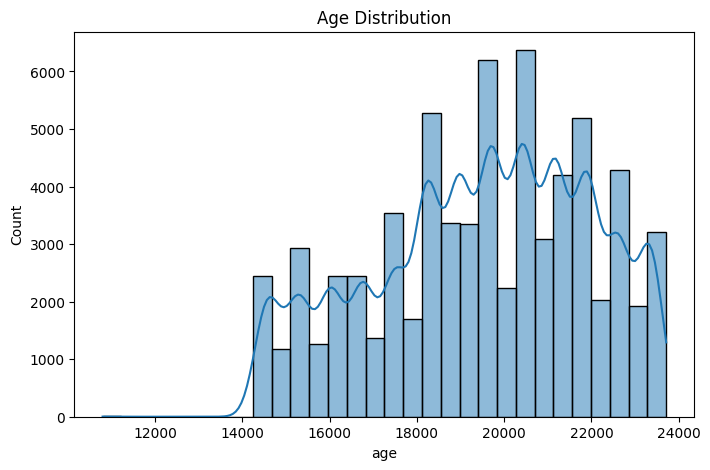

In [6]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

In [7]:
eda_df = df.copy()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

eda_df["country"] = le.fit_transform(
    eda_df["country"]
)

eda_df["occupation"] = le.fit_transform(
    eda_df["occupation"]
)

# Remove non-numeric columns
eda_df.drop(["date"], axis=1, inplace=True)

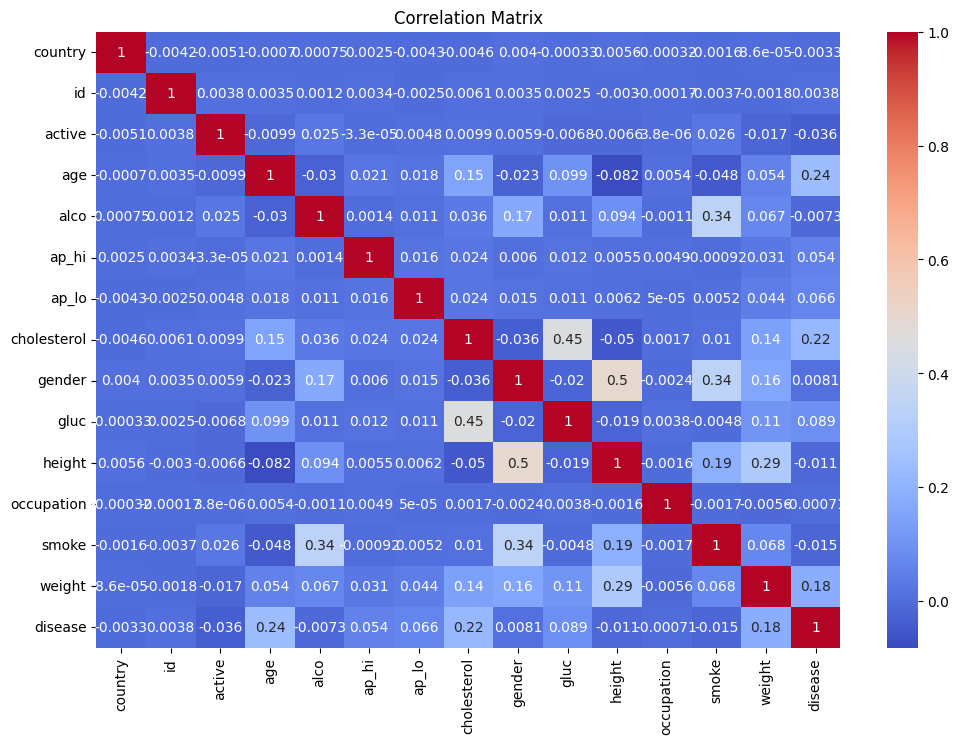

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    eda_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [9]:
df['date'] = pd.to_datetime(
    df['date'],
    dayfirst=True
)

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df.drop(
    ['date', 'id'],
    axis=1,
    inplace=True
)

In [10]:
from sklearn.preprocessing import LabelEncoder

le_country = LabelEncoder()

le_occupation = LabelEncoder()

df['country'] = le_country.fit_transform(
    df['country']
)

df['occupation'] = le_occupation.fit_transform(
    df['occupation']
)

In [11]:
X = df.drop(
    'disease',
    axis=1
)

y = df['disease']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

Logistic regression

In [14]:
log_reg = LogisticRegression(random_state=42)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

accuracy_log = accuracy_score(
    y_test,
    y_pred_log
)

print(
    f"Logistic Regression Accuracy: {accuracy_log*100:.2f}%"
)

Logistic Regression Accuracy: 72.23%


Decision Tree

In [15]:
tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print(
    f"Decision Tree Accuracy: {accuracy_tree*100:.2f}%"
)

Decision Tree Accuracy: 63.21%


Logistic Regression

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Create model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf * 100:.2f}%")

Random Forest Accuracy: 73.30%


Comparision Table

In [22]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_log,
        accuracy_tree,
        accuracy_rf
    ]

})

results

,Model,Accuracy
0,Logistic Regression,0.722286
1,Decision Tree,0.632071
2,Random Forest,0.733000


Accuracy chart

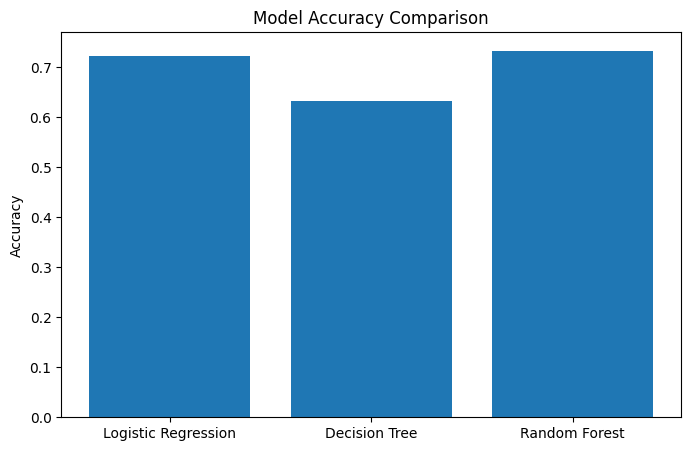

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title(
    "Model Accuracy Comparison"
)

plt.ylabel("Accuracy")

plt.show()

In [24]:
print(df.shape)
print(df['disease'].value_counts())

(70000, 17)
disease
0    35021
1    34979
Name: count, dtype: int64


In [25]:
print(df.corr(numeric_only=True)['disease']
      .sort_values(ascending=False))

disease        1.000000
age            0.238159
cholesterol    0.221147
weight         0.181660
gluc           0.089307
ap_lo          0.065719
ap_hi          0.054475
gender         0.008109
day            0.004708
occupation    -0.000714
year          -0.001353
country       -0.003253
month         -0.003824
alco          -0.007330
height        -0.010821
smoke         -0.015486
active        -0.035653
Name: disease, dtype: float64


In [26]:
df['bmi'] = df['weight'] / ((df['height']/100) ** 2)

In [27]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

In [28]:
X = df.drop(
    [
        'disease',
        'day',
        'month',
        'year'
    ],
    axis=1
)

y = df['disease']

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7385714285714285


In [31]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

           Feature  Importance
4            ap_hi    0.255123
2              age    0.142832
5            ap_lo    0.128506
14  pulse_pressure    0.114211
13             bmi    0.082119
12          weight    0.063751
6      cholesterol    0.060795
9           height    0.051402
10      occupation    0.035090
0          country    0.021921
8             gluc    0.014787
1           active    0.009621
7           gender    0.008467
11           smoke    0.006370
3             alco    0.005003


In [32]:
important_features = [
    'ap_hi',
    'age',
    'ap_lo',
    'pulse_pressure',
    'bmi',
    'weight',
    'cholesterol',
    'height'
]

X = df[important_features]
y = df['disease']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7329285714285714


In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      6988
           1       0.75      0.69      0.72      7012

    accuracy                           0.73     14000
   macro avg       0.73      0.73      0.73     14000
weighted avg       0.73      0.73      0.73     14000

